# EV Sri Lanka: Exploratory & Advanced Analysis

This notebook analyzes EV vehicle imports across Sri Lanka by vehicle category, brand,
district, and time. It includes exploratory data analysis (EDA) as well as advanced
analysis: time series forecasting, geographic category mix comparison, and k-means
clustering of districts by adoption pattern.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/ev_cleaned.csv")
df.head()

,vehicle_category,make,model,manufacture_year,district,count
0,THREE WHEELER,BAJAJ,AR4S-UG,2010.0,COLOMBO,1
1,MOTOR CYCLE,SOURCE LINK,CAGW01,2016.0,COLOMBO,1
2,CAR,MERCEDES BENZ,B CLASS,2016.0,COLOMBO,2
3,MOTOR CYCLE,RW,JINBAO,2016.0,COLOMBO,5
4,MOTOR CYCLE,RW,HANBAO,2016.0,PUTTALAM,1


In [3]:
print("Total records:", len(df))
print("Total vehicles (sum of count):", df['count'].sum())
print("Year range:", df['manufacture_year'].min(), "-", df['manufacture_year'].max())
print("Number of districts:", df['district'].nunique())
print("Number of vehicle categories:", df['vehicle_category'].nunique())
print("Number of unique makes:", df['make'].nunique())

Total records: 6536
Total vehicles (sum of count): 65197
Year range: 1965.0 - 2025.0
Number of districts: 25
Number of vehicle categories: 10
Number of unique makes: 314


In [4]:
print(df['manufacture_year'].dtype)

float64


In [5]:
df['manufacture_year'] = df['manufacture_year'].astype('Int64')
print(df['manufacture_year'].dtype)

Int64


In [6]:
category_totals = df.groupby('vehicle_category')['count'].sum().sort_values(ascending=False)
print(category_totals)

vehicle_category
MOTOR CYCLE                  51795
CAR                          12761
THREE WHEELER                  435
DUAL PURPOSE (COMMERCIAL)       96
MOTOR TRICYCLE VAN              48
SPECIAL PURPOSE VEHICLE         29
SINGLE CAB                      25
LAND VEHICLE (SMALL)             5
MOTOR LORRY (COMMERCIAL)         2
THREE WHEELER CAR                1
Name: count, dtype: int64


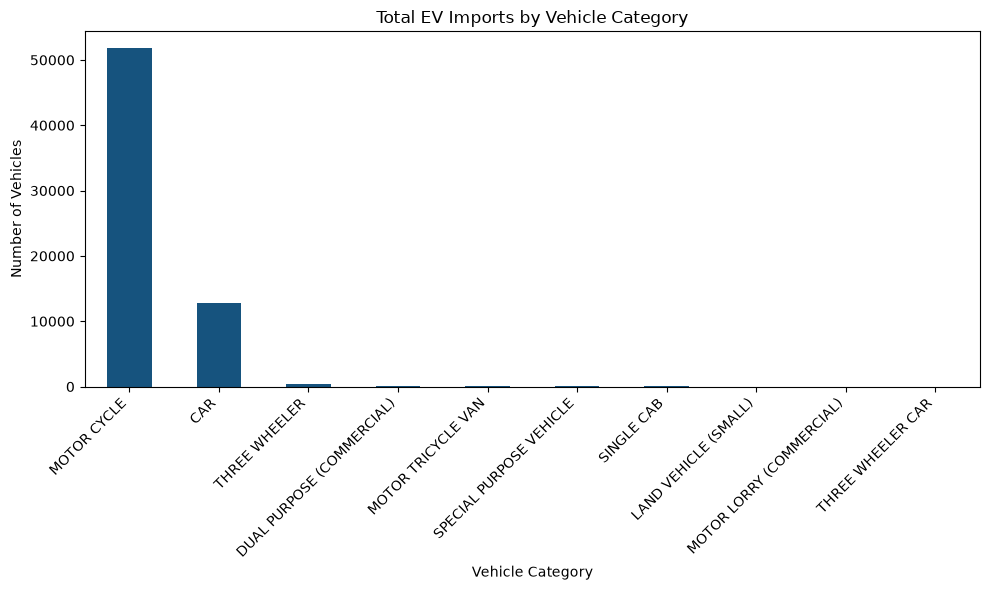

In [7]:
plt.figure(figsize=(10,6))
category_totals.plot(kind='bar', color='#16537e')
plt.title('Total EV Imports by Vehicle Category')
plt.ylabel('Number of Vehicles')
plt.xlabel('Vehicle Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/category_distribution.png', dpi=150)
plt.show()

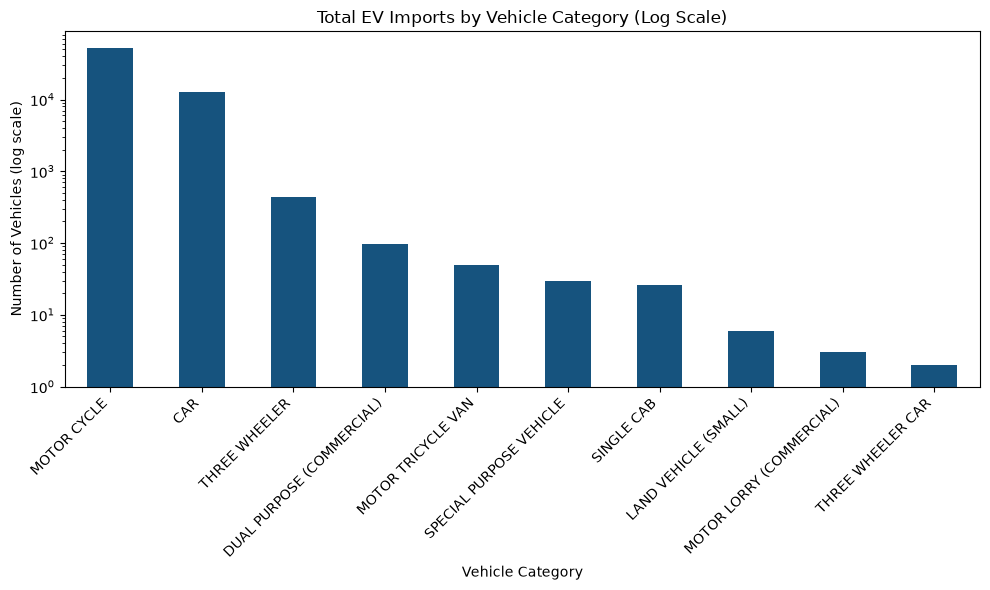

In [8]:
plt.figure(figsize=(10,6))
category_totals.plot(kind='bar', color='#16537e', log=True)
plt.title('Total EV Imports by Vehicle Category (Log Scale)')
plt.ylabel('Number of Vehicles (log scale)')
plt.xlabel('Vehicle Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/category_distribution_log.png', dpi=150)
plt.show()

### Vehicle Category Distribution

EV imports in Sri Lanka are overwhelmingly dominated by **motorcycles**, which account for
approximately **79%** of all registered EV imports (51,795 of 65,197 vehicles), followed by
**cars** at roughly **20%** (12,761 vehicles). All remaining categories combined — three
wheelers, dual purpose commercial vehicles, motor tricycle vans, and others — make up less
than **1%** of total imports.

A standard linear-scale bar chart makes this imbalance visually accurate but analytically
unhelpful, since every category outside motorcycles and cars appears indistinguishable from
zero. A **log-scale bar chart** is used instead, which preserves the true magnitude of
motorcycle dominance while still making it possible to compare the smaller categories to
one another.

**Key takeaway:** Sri Lanka's EV adoption story is, in practice, primarily a story of
electric motorcycle adoption, not electric cars.

### Top Vehicle Makes

Since `make` has 314 unique values, we focus on the top 15 by total vehicles imported
(summed via `count`, since each row represents an aggregated group rather than a
single vehicle). This shows which brands are actually driving Sri Lanka's EV import volume.

In [9]:
top_makes = df.groupby('make')['count'].sum().sort_values(ascending=False).head(15)
print(top_makes)

make
YADEA          29603
NISSAN          4529
BYD             4366
NWOW            2856
AIMA            2206
RISE            2136
LIMA            1517
QUANLE          1491
TVS             1480
SOLID           1268
LUYUAN          1199
TMR QUANLE       939
TOYOTA           902
BAW              865
LUYUAN ALFA      809
Name: count, dtype: int64


In [10]:
# Group by make and sum the 'count' column (not row count, since data is pre-aggregated)
# Take the top 15 makes by total vehicles imported
top_makes = df.groupby('make')['count'].sum().sort_values(ascending=False).head(15)
print(top_makes)

make
YADEA          29603
NISSAN          4529
BYD             4366
NWOW            2856
AIMA            2206
RISE            2136
LIMA            1517
QUANLE          1491
TVS             1480
SOLID           1268
LUYUAN          1199
TMR QUANLE       939
TOYOTA           902
BAW              865
LUYUAN ALFA      809
Name: count, dtype: int64


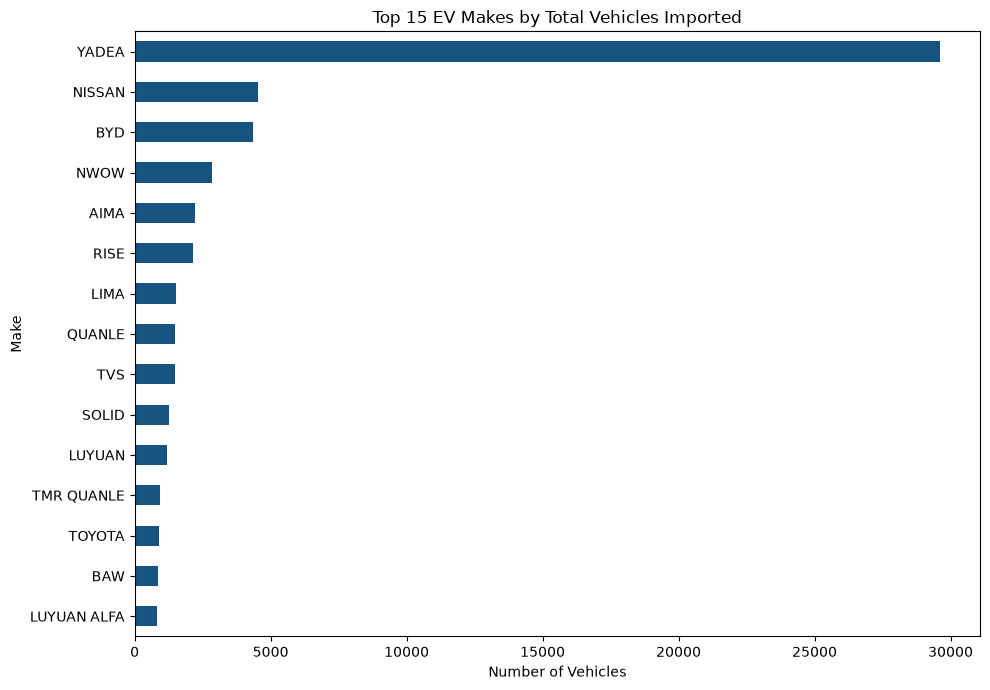

In [11]:
# Horizontal bar chart of top 15 makes by total vehicles imported
plt.figure(figsize=(10,7))
top_makes.sort_values().plot(kind='barh', color='#16537e')
plt.title('Top 15 EV Makes by Total Vehicles Imported')
plt.xlabel('Number of Vehicles')
plt.ylabel('Make')
plt.tight_layout()
plt.savefig('../visuals/top_makes.png', dpi=150)
plt.show()

### Top Vehicle Makes

**YADEA** dominates Sri Lanka's EV import market, accounting for roughly **45%** of all
imported EVs (29,603 of 65,197 vehicles) — more than the next several brands combined.
This aligns with the earlier finding that motorcycles drive the vast majority of EV imports,
since YADEA is primarily an electric motorcycle/scooter manufacturer.

**NISSAN** and **BYD** are the leading electric car brands (4,529 and 4,366 vehicles
respectively), but at roughly 1/7th the volume of YADEA. **TOYOTA** is the only other
traditional automaker to appear in the top 15, with a small fraction of YADEA's volume.

**Key takeaway:** the EV import market in Sri Lanka is not evenly split between competing
car and motorcycle brands — it is heavily concentrated around a single dominant motorcycle
brand, with car brands playing a comparatively minor role in overall volume.

In [12]:
# Total vehicles imported per district (sum of count, since data is pre-aggregated)
district_totals = df.groupby('district')['count'].sum().sort_values(ascending=False)
print(district_totals)

district
COLOMBO         12104
GAMPAHA          8886
KURUNEGALA       8152
ANURADHAPURA     4753
HAMBANTOTA       4329
GALLE            4048
KALUTARA         3582
PUTTALAM         2794
MATARA           2554
POLONNARUWA      2298
MONERAGALA       1602
RATNAPURA        1558
JAFFNA           1332
KANDY            1199
AMPARA           1138
MATALE           1078
TRINCOMALEE       793
KEGALLE           670
KILINOCHCHI       524
BADULLA           518
BATTICALOA        374
MULLATIVU         322
VAVUNIYA          278
MANNAR            218
NUWARA-ELIYA       93
Name: count, dtype: int64


### District-Level EV Distribution

We look at total vehicles imported per district (summed via `count`) to understand the
geographic spread of EV adoption across Sri Lanka. Unlike the vehicle category and make
data, we expect this to correlate somewhat with population and economic activity, since
more populated/urban districts generally register more vehicles overall.

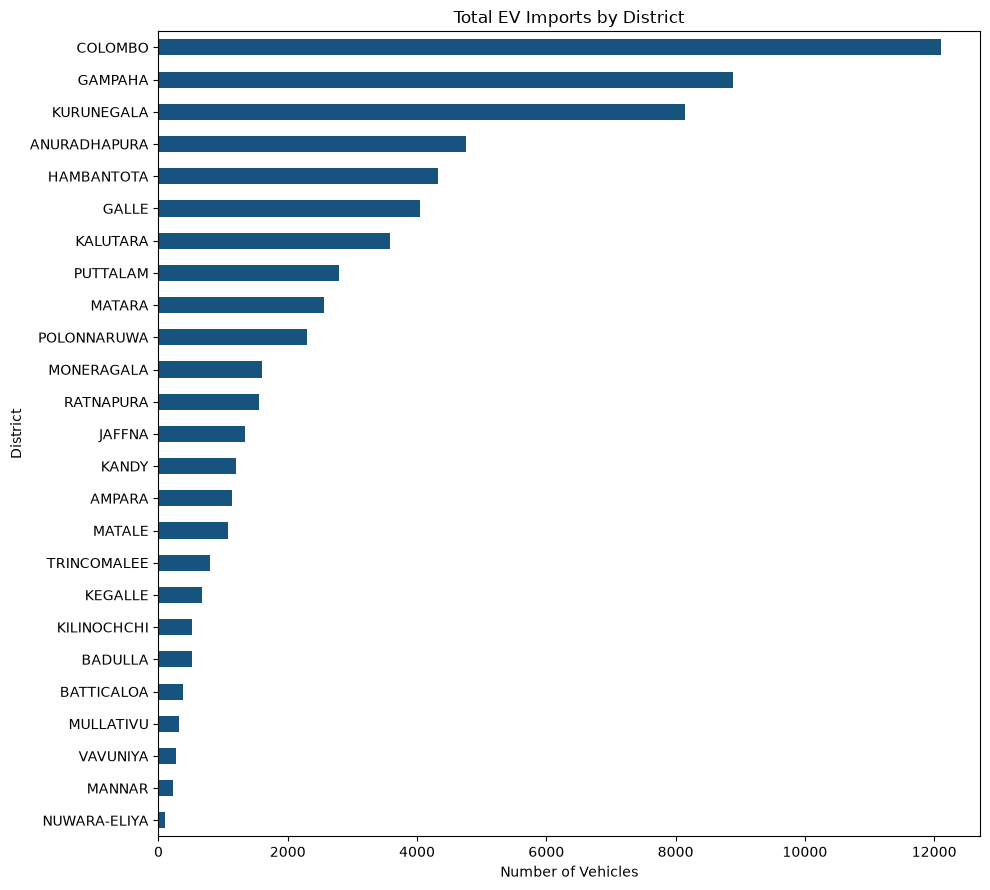

In [13]:
# Horizontal bar chart of all 25 districts by total vehicles imported, sorted ascending for readability
plt.figure(figsize=(10,9))
district_totals.sort_values().plot(kind='barh', color='#16537e')
plt.title('Total EV Imports by District')
plt.xlabel('Number of Vehicles')
plt.ylabel('District')
plt.tight_layout()
plt.savefig('../visuals/district_distribution.png', dpi=150)
plt.show()

**Key findings:**
- **Colombo** (12,104), **Gampaha** (8,886), and **Kurunegala** (8,152) are the top three
  districts, together accounting for roughly **44%** of all EV imports nationwide.
- Colombo and Gampaha are Sri Lanka's most populous and economically active districts,
  which likely explains their dominance — more vehicle registrations overall, not
  necessarily higher EV *adoption rates* specifically.
- **Nuwara-Eliya** (93), **Mannar** (218), and **Vavuniya** (278) have the lowest EV import
  volumes — over 100x lower than Colombo — likely reflecting smaller populations and more
  rural, less urbanized economies in these areas.
- This raw count view is influenced heavily by district population size. A more precise
  view of *EV adoption rate* would require normalizing by population or by total vehicle
  registrations per district (data not available in this dataset) — a limitation worth
  noting rather than over-interpreting raw totals as adoption enthusiasm.

## Time Trend Analysis

We now look at how EV imports have changed over time, using `manufacture_year`. Note that
12 rows have an unknown year (set to missing during cleaning) and are automatically
excluded here, since grouping by year requires a valid year value.

In [14]:
# Drop rows with missing manufacture_year (can't group these by year), then sum count per year
yearly_totals = df.dropna(subset=['manufacture_year']).groupby('manufacture_year')['count'].sum()
print(yearly_totals)

manufacture_year
1965        1
1973        1
1980        1
1999        1
2002        2
2003        1
2004        1
2005       26
2006        8
2007        6
2008       18
2009        7
2010       16
2011       62
2012      971
2013     1866
2014     1715
2015      937
2016      933
2017      827
2018     1085
2019      468
2020      107
2021       59
2022     1385
2023     4041
2024    17222
2025    33418
Name: count, dtype: int64


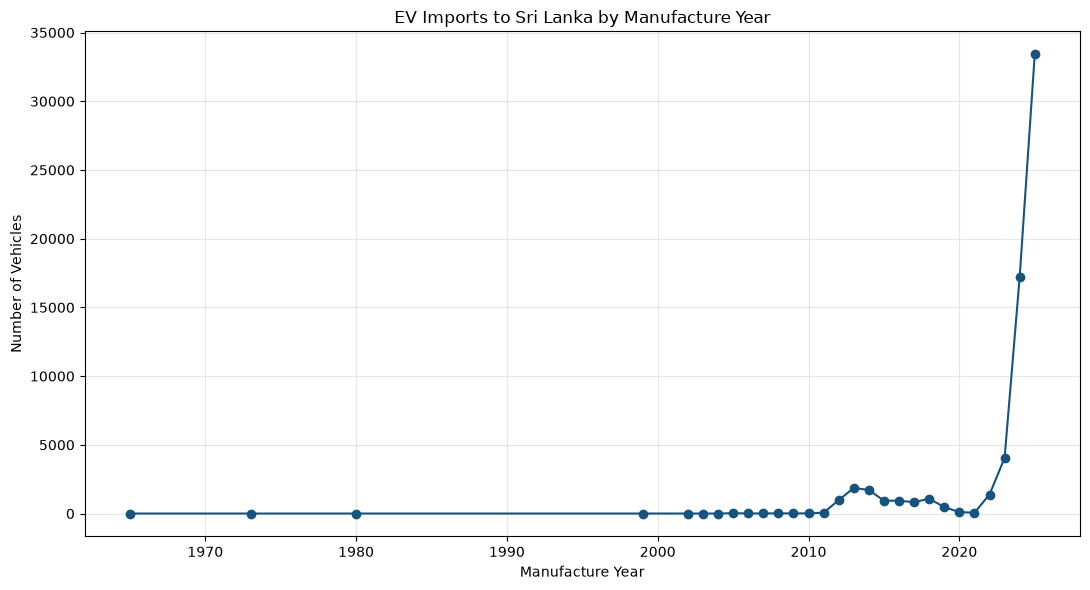

In [15]:
# Line chart of total EV imports by manufacture year, showing overall adoption trend over time
plt.figure(figsize=(11,6))
yearly_totals.plot(kind='line', marker='o', color='#16537e')
plt.title('EV Imports to Sri Lanka by Manufacture Year')
plt.xlabel('Manufacture Year')
plt.ylabel('Number of Vehicles')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/yearly_trend.png', dpi=150)
plt.show()

**Key findings:**
- EV imports were nearly non-existent before 2011 (single-digit vehicle counts most years),
  consistent with EVs being a very new technology globally during that period.
- A first, smaller wave of adoption appears between 2012 and 2018, peaking around
  1,000–1,900 vehicles per year, before dropping off in 2019–2021 (2020–2021 in particular
  coincide with the COVID-19 pandemic, a plausible explanation for the dip given global
  supply chain and import disruptions during that period).
- From 2022 onward, imports grow dramatically: 1,385 (2022) -> 4,041 (2023) -> 17,222 (2024)
  -> 33,418 (2025) - roughly an **8x increase between 2023 and 2025 alone**. 2025 by itself
  accounts for over half of all EV vehicles ever imported in this dataset.
- This suggests Sri Lanka's EV adoption is a very recent and rapidly accelerating
  phenomenon, likely driven by some combination of falling EV prices, improved charging
  infrastructure, and/or policy changes (import tax/duty changes are a plausible driver,
  though this dataset alone cannot confirm the specific cause).

## Forecasting Future EV Imports

Using the yearly import totals, we build a simple forecast for the next 1-2 years. Given
the small sample size (especially reliable data really only from ~2011 onward) and the
extreme recent growth (2023-2025), we use a simple linear regression as a first approach -
not because it's the most sophisticated method, but because with this little data, a
complex model would overfit and give a false sense of precision. We are explicit about this
limitation rather than presenting the forecast as highly reliable.

In [16]:
# Filter to recent years only (2011 onward), where EV import activity is actually meaningful
recent = yearly_totals[yearly_totals.index >= 2011].reset_index()
recent.columns = ['year', 'total_count']
print(recent)

    year  total_count
0   2011           62
1   2012          971
2   2013         1866
3   2014         1715
4   2015          937
5   2016          933
6   2017          827
7   2018         1085
8   2019          468
9   2020          107
10  2021           59
11  2022         1385
12  2023         4041
13  2024        17222
14  2025        33418


In [17]:
# Fit a simple linear regression: year -> total_count, then predict next 2 years
from sklearn.linear_model import LinearRegression
import numpy as np

X = recent[['year']]
y = recent['total_count']

model = LinearRegression()
model.fit(X, y)

future_years = pd.DataFrame({'year': [2026, 2027]})
predictions = model.predict(future_years)

for yr, pred in zip(future_years['year'], predictions):
    print(f"Predicted EV imports in {yr}: {int(pred):,}")

Predicted EV imports in 2026: 13,937
Predicted EV imports in 2027: 15,136


**Forecast results and limitations:**

The linear regression model predicts approximately **13,937 vehicles for 2026** and
**15,136 for 2027**. However, this is very likely a significant **underestimate**, since
2025 alone already recorded 33,418 vehicles - more than double the model's 2026 prediction.

This happens because linear regression assumes a constant rate of growth across the entire
15-year period (2011-2025), which averages out the flat years (e.g. 2019-2021) with the
extreme recent surge (2023-2025). It cannot capture an accelerating, non-linear growth
pattern.

A more appropriate model would need to weight recent years more heavily, or use a
model built for exponential/non-linear growth (e.g. polynomial regression, or a proper
time-series method). Given the very small sample size (only 15 data points, with only
3 years of extreme growth), any forecast here should be treated as a rough directional
estimate, not a precise prediction - the honest conclusion is that the trend is currently
too new and volatile to forecast reliably with confidence.

In [18]:
# Compare: fit only on the most recent 4 years to capture the recent acceleration
recent_short = recent[recent['year'] >= 2022]
model_short = LinearRegression()
model_short.fit(recent_short[['year']], recent_short['total_count'])
short_predictions = model_short.predict(future_years)

for yr, pred in zip(future_years['year'], short_predictions):
    print(f"Short-term trend prediction for {yr}: {int(pred):,}")

Short-term trend prediction for 2026: 41,336
Short-term trend prediction for 2027: 52,264


**Comparing long-term vs. short-term trend models:**

| Model | 2026 Prediction | 2027 Prediction |
|---|---|---|
| Full history (2011-2025) | 13,937 | 15,136 |
| Recent trend only (2022-2025) | 41,336 | 52,264 |

The two models disagree by nearly **3x** for 2026 alone. This gap itself is the real
finding: it demonstrates that EV adoption in Sri Lanka has fundamentally changed pace in
the last 2-3 years, and any model trained on the full 15-year history dilutes and
underestimates this shift. The recent-trend model is likely closer to reality *if* the
current acceleration continues, but it also carries risk: it assumes the extreme 2023-2025
growth rate persists indefinitely, which is rarely sustainable long-term (markets typically
plateau as they mature, due to factors like market saturation, charging infrastructure
limits, or policy changes).

**Conclusion:** rather than presenting a single forecast number, the more honest and useful
insight is that Sri Lanka's EV import growth is currently in a steep acceleration phase,
and any forecast should be treated as a rough directional signal, not a precise prediction,
given the limited historical data and the market's early, volatile stage.

## Geographic Analysis: Category Mix by District

Raw district totals (done earlier) mainly reflect population size. A more interesting
question is whether different districts have different *patterns* of EV adoption - for
example, do urban districts import proportionally more cars, while rural districts import
proportionally more motorcycles? We explore this using a cross-tabulation of district vs.
vehicle category.

In [19]:
# Cross-tabulate district and vehicle_category, summing the count column
district_category = df.pivot_table(
    index='district',
    columns='vehicle_category',
    values='count',
    aggfunc='sum',
    fill_value=0
)
print(district_category)

vehicle_category   CAR  DUAL PURPOSE (COMMERCIAL)  LAND VEHICLE (SMALL)  \
district                                                                  
AMPARA              44                          0                     0   
ANURADHAPURA       103                          1                     0   
BADULLA            105                          0                     0   
BATTICALOA          28                          0                     0   
COLOMBO           6111                         53                     0   
GALLE              584                          1                     0   
GAMPAHA           2409                         15                     0   
HAMBANTOTA         122                          0                     0   
JAFFNA              65                          0                     0   
KALUTARA           744                          6                     0   
KANDY              683                          3                     0   
KEGALLE            182   

In [20]:
# Calculate what percentage of each district's (car + motorcycle) total is cars
# This normalizes for district size, letting us compare the *mix*, not just raw volume
car_vs_bike = district_category[['CAR', 'MOTOR CYCLE']].copy()
car_vs_bike['car_share_pct'] = (
    car_vs_bike['CAR'] / (car_vs_bike['CAR'] + car_vs_bike['MOTOR CYCLE']) * 100
).round(1)
car_vs_bike = car_vs_bike.sort_values('car_share_pct', ascending=False)
print(car_vs_bike)

vehicle_category   CAR  MOTOR CYCLE  car_share_pct
district                                          
KANDY              683          504           57.5
COLOMBO           6111         5720           51.7
NUWARA-ELIYA        37           54           40.7
KEGALLE            182          473           27.8
GAMPAHA           2409         6363           27.5
BADULLA            105          395           21.0
KALUTARA           744         2810           20.9
RATNAPURA          236         1314           15.2
GALLE              584         3429           14.6
MATARA             306         2232           12.1
PUTTALAM           261         2508            9.4
BATTICALOA          28          343            7.5
MATALE              78          994            7.3
KURUNEGALA         543         7586            6.7
JAFFNA              65         1253            4.9
VAVUNIYA            12          265            4.3
AMPARA              44         1090            3.9
MONERAGALA          50         

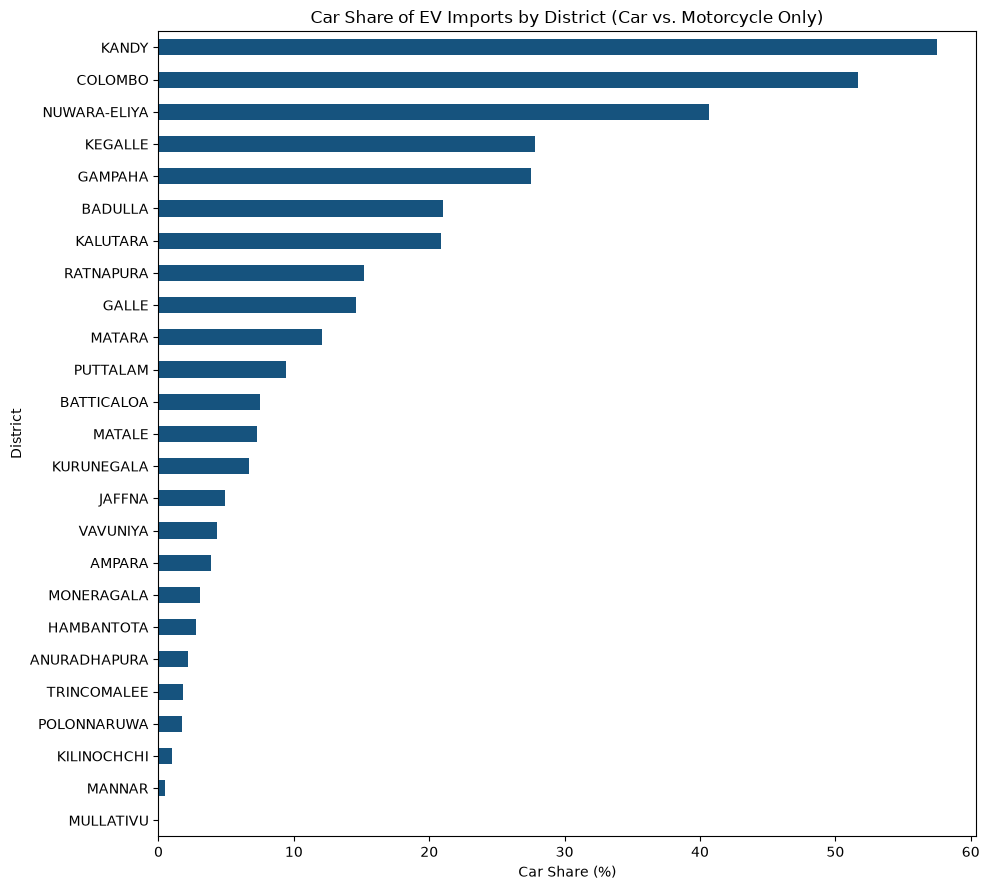

In [21]:
# Horizontal bar chart of car share % by district, sorted for readability
plt.figure(figsize=(10,9))
car_vs_bike['car_share_pct'].sort_values().plot(kind='barh', color='#16537e')
plt.title('Car Share of EV Imports by District (Car vs. Motorcycle Only)')
plt.xlabel('Car Share (%)')
plt.ylabel('District')
plt.tight_layout()
plt.savefig('../visuals/car_share_by_district.png', dpi=150)
plt.show()

**Key findings:**

- **Kandy** (57.5%) and **Colombo** (51.7%) are the only two districts where cars make up
  more than half of car+motorcycle EV imports - notably, Kandy edges out Colombo, which
  goes against the initial assumption that Colombo (the largest, most urban district) would
  be the clear leader in car share.
- A large group of districts in the 15-30% range (Nuwara-Eliya, Kegalle, Gampaha, Badulla,
  Kalutara, Ratnapura) show a more moderate but still motorcycle-leaning mix.
- The remaining majority of districts, especially in the North and East (Mullativu,
  Mannar, Kilinochchi, Vavuniya, Trincomalee, Polonnaruwa) and parts of the dry zone
  (Anuradhapura, Hambantota, Moneragala), have car shares below 5% - EV adoption in these
  areas is almost entirely in the motorcycle segment.
- **Interpretation:** rather than a simple "urban districts prefer cars" story, the pattern
  looks more closely tied to income levels and economic activity concentrated in specific
  hill-country/western districts (Kandy, Colombo), while lower car-share districts align
  with more rural, lower-income, and post-conflict regions (North/East). This dataset alone
  cannot confirm income as the driver - it is a plausible explanation based on general
  knowledge of Sri Lanka's regional economics, not something proven by this data alone.

## Clustering Districts by Vehicle Category Mix

We now group districts based on their overall vehicle category "fingerprint" - not just
car vs. motorcycle, but the full mix across all 10 categories. This can reveal groups of
districts with similar EV adoption patterns, beyond what we found by eye in the geographic
section. We use k-means clustering, a common unsupervised learning technique for grouping
similar data points.

In [22]:
# Convert each district's category counts into proportions (%) of that district's total
# This ensures clustering is based on category MIX, not district SIZE
district_props = district_category.div(district_category.sum(axis=1), axis=0) * 100
print(district_props.round(1))

vehicle_category   CAR  DUAL PURPOSE (COMMERCIAL)  LAND VEHICLE (SMALL)  \
district                                                                  
AMPARA             3.9                        0.0                   0.0   
ANURADHAPURA       2.2                        0.0                   0.0   
BADULLA           20.3                        0.0                   0.0   
BATTICALOA         7.5                        0.0                   0.0   
COLOMBO           50.5                        0.4                   0.0   
GALLE             14.4                        0.0                   0.0   
GAMPAHA           27.1                        0.2                   0.0   
HAMBANTOTA         2.8                        0.0                   0.0   
JAFFNA             4.9                        0.0                   0.0   
KALUTARA          20.8                        0.2                   0.0   
KANDY             57.0                        0.3                   0.0   
KEGALLE           27.2   

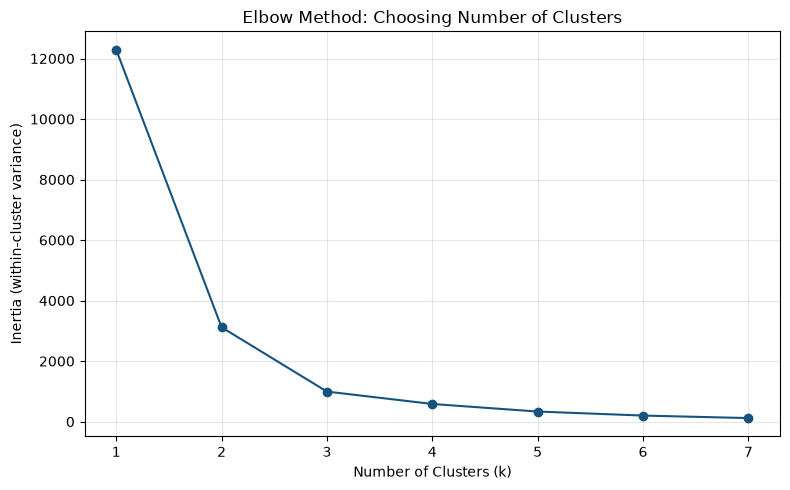

In [23]:
# Elbow method: try different numbers of clusters and see where the improvement levels off
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(district_props)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o', color='#16537e')
plt.title('Elbow Method: Choosing Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (within-cluster variance)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/elbow_method.png', dpi=150)
plt.show()

In [24]:
# Fit final k-means model with k=3 clusters (chosen via elbow method)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_props['cluster'] = kmeans.fit_predict(district_props)

# Show which district fell into which cluster, sorted for readability
print(district_props[['CAR', 'MOTOR CYCLE', 'cluster']].sort_values('cluster'))

vehicle_category        CAR  MOTOR CYCLE  cluster
district                                         
COLOMBO           50.487442    47.257105        0
KANDY             56.964137    42.035029        0
NUWARA-ELIYA      39.784946    58.064516        0
BATTICALOA         7.486631    91.711230        1
HAMBANTOTA         2.818203    96.973897        1
KURUNEGALA         6.660942    93.056919        1
JAFFNA             4.879880    94.069069        1
AMPARA             3.866432    95.782074        1
MANNAR             0.458716    96.788991        1
MATALE             7.235622    92.207792        1
KILINOCHCHI        0.954198    99.045802        1
POLONNARUWA        1.653612    97.954743        1
MULLATIVU          0.000000   100.000000        1
MONERAGALA         3.121099    96.691635        1
MATARA            11.981206    87.392326        1
ANURADHAPURA       2.167052    97.601515        1
TRINCOMALEE        1.765448    97.477932        1
PUTTALAM           9.341446    89.763780        1


### Cluster Interpretation

K-means (k=3, chosen via the elbow method) groups Sri Lanka's 25 districts into three
distinct EV adoption profiles based on category mix:

- **Cluster 0 - "Car-leaning" districts (Colombo, Kandy, Nuwara-Eliya):** the only
  districts where cars exceed 39% of EV imports, with Kandy (57.0%) and Colombo (50.5%)
  roughly balanced between cars and motorcycles. These are Sri Lanka's key urban/hill-country
  economic centers.

- **Cluster 1 - "Heavily motorcycle-dominant" districts (13 districts, including
  Mullativu, Kilinochchi, Polonnaruwa, Anuradhapura, Hambantota):** car share is consistently
  below 12%, with several districts below 5%. This is the largest cluster, and includes
  most of the North, East, and dry zone regions.

- **Cluster 2 - "Moderate mix" districts (Kalutara, Badulla, Kegalle, Galle, Gampaha,
  Ratnapura):** car share sits in a middle range (roughly 14-27%), representing a
  transitional group between the car-leaning outliers and the overwhelmingly
  motorcycle-dominant majority.

**Key takeaway:** rather than a simple urban-vs-rural split, EV adoption patterns cluster
into three clearly separated tiers, with a small, distinct car-leaning group
(Colombo/Kandy/Nuwara-Eliya), a large motorcycle-dominant majority (mostly North, East, and
dry zone districts), and a moderate middle tier (mostly Western and Southern districts).
This structure was consistent with, and now statistically validated, the pattern first
noticed in the district-level car-share analysis earlier in this project.

In [25]:
import os
print(os.listdir('../visuals'))

['car_share_by_district.png', 'category_distribution.png', 'category_distribution_log.png', 'district_distribution.png', 'elbow_method.png', 'top_makes.png', 'yearly_trend.png']


In [26]:
import sys
sys.path.append('..')
from src.cleaning import clean_ev_data

raw = pd.read_excel("../data/raw/ev_importers_sri_lanka_raw.xlsx", sheet_name="Sheet1", header=1)
df_test = clean_ev_data(raw)
df_test.head()

,vehicle_category,make,model,manufacture_year,district,count
0,THREE WHEELER,BAJAJ,AR4S-UG,2010,COLOMBO,1
1,MOTOR CYCLE,SOURCE LINK,CAGW01,2016,COLOMBO,1
2,CAR,MERCEDES BENZ,B CLASS,2016,COLOMBO,2
3,MOTOR CYCLE,RW,JINBAO,2016,COLOMBO,5
4,MOTOR CYCLE,RW,HANBAO,2016,PUTTALAM,1
